### Generating simple training/test set

In [2]:
import matplotlib.pyplot as pl
import pandas as pd
import numpy as np


In [ ]:

pl.scatter(Re_mag_vals[:,0],Re_mag_vals[:,1],s=1)
pl.xlabel('Re')
pl.ylabel('mag')
pl.show()

In [ ]:
mean_Re = 0.5
mean_mag = 19
sigma_Re = 0.1
sigma_mag = 0.1
sigma_offdiag = 0.9*np.sqrt(sigma_Re*sigma_mag) #0.9 of max possible covariance
Re_mag_vals = mvn(mean = [mean_Re,mean_mag],
                 cov = [[sigma_Re**2,sigma_offdiag**2],[sigma_offdiag**2,sigma_mag**2]]).rvs(int(1.1*N_train))
Re_mag_vals = Re_mag_vals[Re_mag_vals[:,0]>0] #Re>0
rand_indx = np.random.choice(np.arange(len(Re_mag_vals)),N_train,replace=False)
Re_mag_vals = Re_mag_vals[rand_indx]


In [ ]:
db = pd.read_csv('/mnt/zfsusers/hollowayp/paltas/datasets/LensPop_databases/LensPop_LSST_Paltas_Catalogue_0.csv')

N_train = int(5e+5)
N_test = int(5e+4)

#Hardcoding a covariance between i-lens and Re_lens:
from scipy.stats import multivariate_normal as mvn
mean_Re = 0.5
mean_mag = 19
sigma_Re = 0.1
sigma_mag = 0.1
sigma_offdiag = 0.9*np.sqrt(sigma_Re*sigma_mag) #0.9 of max possible covariance
Re_mag_vals = mvn(mean = [mean_Re,mean_mag],
                 cov = [[sigma_Re**2,sigma_offdiag**2],[sigma_offdiag**2,sigma_mag**2]]).rvs(int(1.1*N_train))
Re_mag_vals = Re_mag_vals[Re_mag_vals[:,0]>0] #Re>0
rand_indx = np.random.choice(np.arange(len(Re_mag_vals)),N_test,replace=False)
Re_mag_vals = Re_mag_vals[rand_indx]

db_dict = {}
db_dict['test'] = {
    'index':np.arange(N_test),
    'zL':0.5*np.ones(N_test),
    'zS':1.0*np.ones(N_test),
    'tE':np.random.uniform(0.5,2.0,N_test),
    'xs':np.random.uniform(-1.0,1.0,N_test),
    'ys':np.random.uniform(-1.0,1.0,N_test),
    'Re_source':np.random.uniform(0.1,0.5,N_test),
    'Re_lens':Re_mag_vals[:,0],
    'defl_gamma':np.random.uniform(1.8,2.2,N_test),
    'q_source_flat':0.8*np.ones(N_test),
    'q_lens_flat':0.8*np.ones(N_test),
    'i_lens':Re_mag_vals[:,1],
    'i_source':20*np.ones(N_test),
    'source_Ns':1.0*np.ones(N_test),
    'defl_Ns':4.0*np.ones(N_test),
}
for param_i in ['e1_source','e2_source','e1_lens','e2_lens',
                'defl_mass_x','defl_mass_y','defl_light_x','defl_light_y',
                'defl_e1_mass','defl_e2_mass','defl_e1_light','defl_e2_light',
                'defl_gamma1','defl_gamma2']:
    db_dict['test'][param_i] = 0.0*np.ones(N_test)

db_dict['test'] = pd.DataFrame(db_dict['test'])

db_dict['test'].to_csv('./paltas/Configs/Examples/covariance_testing_data.csv',index=False)


In [ ]:
from plot_image_collage import plot_collage
plot_collage(f'{model_folder}/training/0',3,3)

In [ ]:
plot_collage(f'{model_folder}/validation/0',3,3)

In [ ]:
db_0 = pd.read_csv('./paltas_covariance_test/training/0/metadata.csv')
pl.scatter(db_0['lens_light_parameters_R_sersic'],db_0['lens_light_parameters_mag_app'])
pl.show()

In [5]:
for train_folder in range(10):
    print(f"addqueue -c '5hr' -m 12 -q berg --requeue /mnt/users/hollowayp/python114_archive/bin/python3.11 ./paltas/generate.py ./paltas/Configs/Examples/config_catalogue_covariance_check.py /mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_nocov/training/{train_folder} --n 50000 --h5 --tf_record")

print(f"addqueue -c '5hr' -m 12 -q berg --requeue /mnt/users/hollowayp/python114_archive/bin/python3.11 ./paltas/generate.py ./paltas/Configs/Examples/config_catalogue_covariance_check.py /mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_nocov/validation/0/ --n 50000 --h5 --tf_record")

addqueue -c '5hr' -m 12 -q berg --requeue /mnt/users/hollowayp/python114_archive/bin/python3.11 ./paltas/generate.py ./paltas/Configs/Examples/config_catalogue_covariance_check.py /mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_nocov/training/0 --n 50000 --h5 --tf_record
addqueue -c '5hr' -m 12 -q berg --requeue /mnt/users/hollowayp/python114_archive/bin/python3.11 ./paltas/generate.py ./paltas/Configs/Examples/config_catalogue_covariance_check.py /mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_nocov/training/1 --n 50000 --h5 --tf_record
addqueue -c '5hr' -m 12 -q berg --requeue /mnt/users/hollowayp/python114_archive/bin/python3.11 ./paltas/generate.py ./paltas/Configs/Examples/config_catalogue_covariance_check.py /mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_nocov/training/2 --n 50000 --h5 --tf_record
addqueue -c '5hr' -m 12 -q berg --requeue /mnt/users/hollowayp/python114_archive/b

#### Training the model:

In [ ]:
addqueue -c '1day' -m 6 -n 1x4 -s -q gpulong --gputype rtx3070with8gb /mnt/users/hollowayp/python11_env/bin/python3.11 /mnt/users/hollowayp/paltas/paltas/Analysis/train_model.py /mnt/users/hollowayp/paltas/paltas/Analysis/AnalysisConfigs/train_fullcov_check.py --h5

addqueue -c '1day' -m 6 -n 1x4 -s -q cmbgpu --gputype rtx3090with24gb /mnt/users/hollowayp/python11_env/bin/python3.11 /mnt/users/hollowayp/paltas/paltas/Analysis/train_model.py /mnt/users/hollowayp/paltas/paltas/Analysis/AnalysisConfigs/train_fullcov_check.py --h5

#### Generating predictions on test set

In [4]:
model_folder = '/mnt/extraspace/hollowayp/paltas_data/covariance_test/'

In [ ]:
### full_cov_0
### diag_cov_0: As above, with diag cov
### diag_cov_1: As above, with learning rate changed from 5e-3 to 5e-4 to reduce overfitting
### diag_cov_2: As above, with learning rate changed from 5e-4 to 5e-5 to reduce overfitting further (this seemed to make things even worse)
### diag_cov_3: As above, with batch size changed from 256 to 1024 to reduce overfitting.
### diag_cov_4: As above, with learning rate bacl to 5e-3 (but batch-size=1024) => Much better, but still overfits quickly
### diag_cov_5: As above, adding einstein radius as a learning parameter to make it harder.
### diag_cov_6: As above, with 500k training set and 50k validation set.

### => Realised the scipy.uniform distributions were (loc,scale) not (min,max). Have since adjusted but not regenerated training sets/retrained
### diag_cov_7: As above, with uniform distribution bug fixed. python3.11-59871.out
### diag_cov_8: As above, with non-zero ellipticity/shear U(-0.1,0.1) to make it harder. python3.11-59923.out

### diag_cov_9: Changing lens_light_R_sersic from mean=0.5 to mean=1.1. Similarly changing lens_light_mag_app from mean=19 to 17.6
### diag_cov_10: Changin theta_E from uniform(loc=0.5,scale=1.5).rvs to uniform(loc=1.0,scale=1.0).rvs

### diag_cov_11: Changing learning rate to 5e-5.

### diag_cov_12: Aargh. Making it simple and removing covariance in the training set. Learning rate back to 5e-3.
'''
Previously:
mean_Re = 1.1
mean_mag = 17.6
sigma_Re = 0.1
sigma_mag = 0.1
sigma_offdiag = 0.9*np.sqrt(sigma_Re*sigma_mag) #0.9 of max possible covariance
Re_mag_dist = dist.TruncatedMultivariateNormal(np.array([mean_mag,mean_Re]),
                                               np.array([[sigma_mag**2,sigma_offdiag**2],
                                                         [sigma_offdiag**2,sigma_Re**2]]),
                                               np.array([0,0]),None)
And also:
'theta_E':uniform(loc=1.0,scale=1.0).rvs,
And also:
'cross_object':{
'parameters':{
'lens_light:mag_app,lens_light:R_sersic':Re_mag_dist}}}

Now:
'theta_E':uniform(loc=2.0,scale=1.0).rvs,
'mag_app':17.6,
'R_sersic':uniform(loc=1.0,scale=1.0),
'''

   epoch      loss   val_loss
0      1 -1.385233   6.246130
1      2 -2.831752  -3.302062
2      3 -3.370911  -2.731421
3      4 -3.940233  52.301144
4      5 -4.455331  16.067141
5      6 -4.766909  13.013168
6      7 -4.864468  18.632277
7      8 -5.069193  41.234661
8      9 -5.067070  25.150818
9     10 -5.210674   6.780441


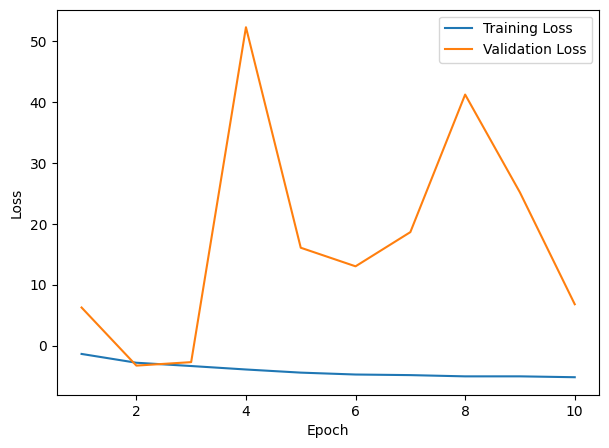

In [6]:
# model_subfolder = '/paltas_covariance_test_500k_nocov/diag_cov_12/'
model_subfolder = '/paltas_covariance_test_500k_fix1/diag_cov_7/'

# Loss plot:
loss_db = pd.read_csv(f'{model_folder}/{model_subfolder}/loss_function_db.csv')
loss_db.drop('Unnamed: 0',axis=1,inplace=True)
print(loss_db)
fig,ax = pl.subplots(figsize=(7,5))
ax.plot(loss_db['epoch'],loss_db['loss'],label='Training Loss')
ax.plot(loss_db['epoch'],loss_db['val_loss'],label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
# ax.set_xlim(0,10)
# ax.set_ylim(-6,6)
pl.show()

In [ ]:
from load_model import load_model,load_model_weights_list,return_final_epoch_weights,return_list_of_weight_files

model_path = f'{model_folder}/paltas_covariance_test_500k_mag_ellip_tE/diag_cov_10/model_weights/19--4.54.h5'
loss_type = 'diag'
learning_params = ['lens_light_parameters_mag_app',
                    'lens_light_parameters_R_sersic',
                    'main_deflector_parameters_theta_E']
model_type = 'xresnet34'
img_size = 60
model = model_dict = {} 

model,loss_func,num_params = load_model(model_path,loss_type=loss_type,learning_params=learning_params,\
                        log_learning_params=[],model_type=model_type,img_size=(img_size,img_size,1))

In [7]:
import sys
from importlib import reload
try: reload(sys.modules['generate_predictions'])
except: print('Could not reload generate_predictions')
from generate_predictions import gen_network_predictions_general
y_test, y_pred, std_pred, prec_pred = gen_network_predictions_general(
                test_folder='/mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_mag_ellip_tE/validation/0',
                norm_path = '/mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_mag_ellip_tE/training/1/norms.csv',
                learning_params=learning_params,
    log_learning_params=[],
    loss_type=loss_type,
    loss_func=loss_func,
    model=model,
    norm_images=True,
    log_norm_images=False,
    h5_or_not='True',
    N_max=10000,
    diag_cov = True,
    specific_file_with_no_ground_truth=False,
    return_prec=True)

y_test = y_test[:,0,0,:]

Could not reload generate_predictions
Using 50000 images as a validation set, from /mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_mag_ellip_tE/validation/0


100%|██████████| 10000/10000 [00:01<00:00, 7842.26it/s]


Y_test (1, 3)
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 80ms/step
Unnormalising outputs
(10000, 1, 1, 3)


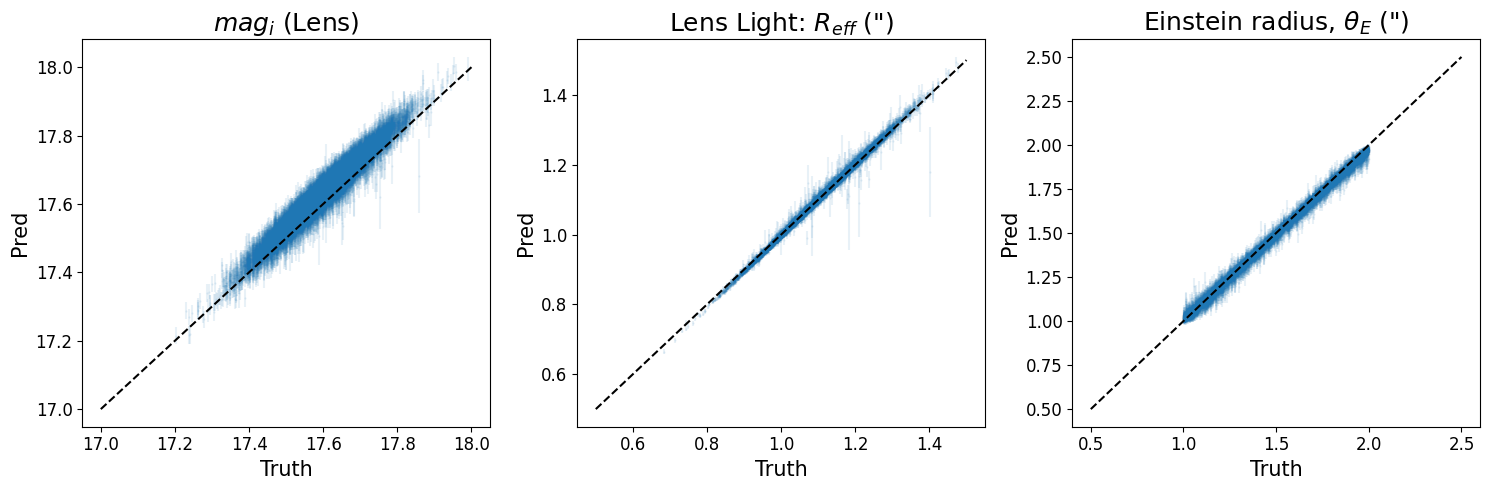

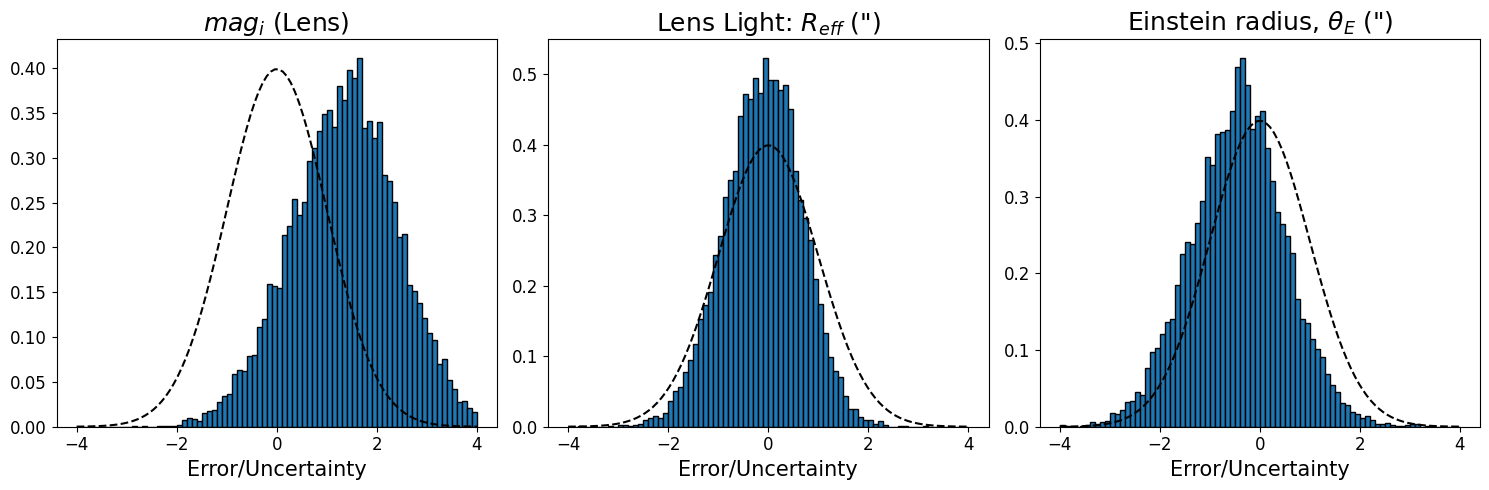

In [10]:
range_dict = {'lens_light_parameters_mag_app':(17,18),
              'lens_light_parameters_R_sersic':(0.5,1.5),
              'main_deflector_parameters_theta_E':(0.5,2.5)}
from parameter_dicts import title_dict
from scipy.stats import norm
N_params = len(learning_params)

### Truth vs Prediction
fig,ax = pl.subplots(1,N_params,figsize=(5*N_params,5))
for p_i,param_i in enumerate(learning_params):
    ax[p_i].errorbar(y_test[:,p_i],y_pred[:,p_i],yerr=std_pred[:,p_i],fmt='.',alpha=0.1,markersize=1)
    ax[p_i].plot(range_dict[param_i],range_dict[param_i],'k--',zorder=4)
    ax[p_i].set_title(title_dict[param_i],size=18)
    ax[p_i].set_xlabel('Truth',size=15)
    ax[p_i].set_ylabel('Pred',size=15)
    ax[p_i].tick_params(labelsize=12)
pl.tight_layout()
pl.show()

### Error vs Uncertainty
fig,ax = pl.subplots(1,N_params,figsize=(5*N_params,5))
X_plot = np.linspace(-4,4,100)
for p_i,param_i in enumerate(learning_params):
    Error_i = y_pred[:,p_i]-y_test[:,p_i]
    Uncertainty_i = std_pred[:,p_i]
    ax[p_i].hist(Error_i/Uncertainty_i,bins=np.linspace(-4,4,81),density=True,edgecolor='k')
    ax[p_i].plot(X_plot,norm.pdf(X_plot),'k--')
    ax[p_i].set_title(title_dict[param_i],size=18)
    ax[p_i].set_xlabel('Error/Uncertainty',size=15)
    ax[p_i].tick_params(labelsize=12)
pl.tight_layout()
pl.show()

In [ ]:
pl.hist(db['Magnification'],bins=np.linspace(1,10,19))
pl.show()

In [ ]:
import corner
db = pd.read_csv('/mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_mag_ellip_tE/training/0/metadata.csv')
corner.corner(db[[elem for elem in db.columns if (len(set(db[elem]))>1) and elem!='detector_parameters_background_noise' and elem!='seed']])
pl.tight_layout()    
pl.show()

In [ ]:
from plot_image_collage import plot_collage
plot_collage('/mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_mag_ellip_tE/training/0',5,5)
plot_collage('/mnt/extraspace/hollowayp/paltas_data/covariance_test/paltas_covariance_test_500k_mag_ellip_tE/validation/0',5,5)